In [2]:
pip install pandas numpy scikit-learn tensorflow matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

fake_path = r"C:\Users\nshaw\Downloads\archive\News_Dataset\Fake.csv"
true_path = r"C:\Users\nshaw\Downloads\archive\News_Dataset\True.csv"

fake = pd.read_csv(fake_path)
true = pd.read_csv(true_path)

print(fake.head())
print(true.head())


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [4]:
fake["label"] = 0
true["label"] = 1

In [5]:
df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

In [6]:
df.head()
df.shape

(44898, 5)

In [7]:
df = df[['text', 'label']]
df.head()

,text,label
0,Rep. Maxine Waters (D-CA) is the physical embo...,0
1,Imam Tawhidi is an outspoken voice in the Musl...,0
2,ANKARA (Reuters) - Turkish authorities have de...,1
3,AMMAN (Reuters) - Russian and Syrian jets kill...,1
4,"*Hey Justin, I don t have another title and wa...",0


In [8]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

In [11]:
df['text'].iloc[0]

'rep maxine waters dca is the physical embodiment of the antitrump resistance in congress she has openly called for the orange one to be impeached on multiple occasions and rails against him on national television at every opportunity her latest attack on the donald comes via his own favorite platform   twitterof course rep waters participated in the tax day marches that were designed to pressure trump to release his tax returns as every president and presidential candidate has done for decades of course trump broke all the rules of politics and still managed to get elected so the breaking of this particular tradition should come as no surprisewell rep waters has had enough of trump s lies and lack of transparency so she took to twitter to rail trump once againtrump will not release his taxes bc he has something to hide hes only out to enrich himself his wealthy cabinet  white house swamp  maxine waters maxinewaters april   cant be lost in the chaos that trumps campaign is still under 

In [12]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(35918,) (8980,)


In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

In [14]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 300

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print(X_train_pad.shape)

(35918, 300)


In [18]:
import numpy as np

glove_path = r"C:\Users\nshaw\Downloads\archive\glove.6B\glove.6B.100d.txt"

embedding_index = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

print("GloVe loaded:", len(embedding_index))

GloVe loaded: 400000


In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000
max_len = 300
embedding_dim = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

In [20]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [22]:
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

print("Embedding matrix created:", embedding_matrix.shape)

Embedding matrix created: (10000, 100)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [24]:
model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    )
)

model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\nshaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [26]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 195s 341ms/step - accuracy: 0.9080 - loss: 0.2354 - val_accuracy: 0.9587 - val_loss: 0.1197
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 229s 407ms/step - accuracy: 0.9499 - loss: 0.1389 - val_accuracy: 0.9755 - val_loss: 0.0769
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 232s 412ms/step - accuracy: 0.9805 - loss: 0.0603 - val_accuracy: 0.9878 - val_loss: 0.0389
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 209s 373ms/step - accuracy: 0.9872 - loss: 0.0376 - val_accuracy: 0.9902 - val_loss: 0.0309
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 200s 355ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.9908 - val_loss: 0.0260


In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step
Accuracy: 0.9909799554565701
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4680
           1       0.99      0.99      0.99      4300

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



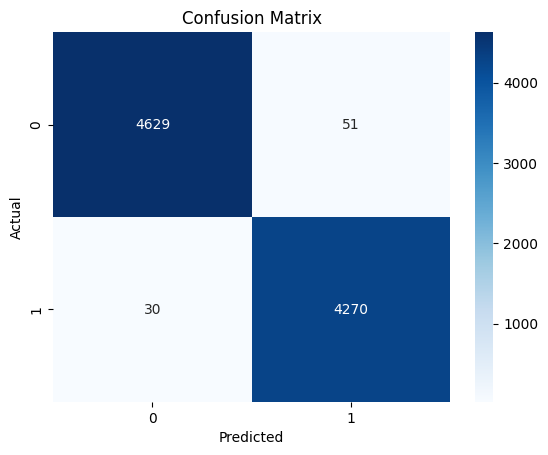

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
def predict_news(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(pad)[0][0]

    return "REAL NEWS" if pred > 0.5 else "FAKE NEWS"

In [31]:
print(predict_news("Government announces free laptops for students"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
FAKE NEWS


In [32]:
git init

SyntaxError: invalid syntax (2830201818.py, line 1)